# Part 1

## TODO 1.1

In [58]:
from sklearn.datasets import fetch_20newsgroups
from collections import Counter

train_data = fetch_20newsgroups(subset='train')
test_data = fetch_20newsgroups(subset='test')

y_train = train_data.target
target_names = train_data.target_names
counts_train = Counter(y_train)

print(f"{'Category':<30}   {'Count'}")
for i in range(len(target_names)):
    print(f"{target_names[i]:<30} | {counts_train[i]}")

majority_baseline_accuracy = max(counts_train.values()) / len(y_train)
print(f"\nMajority Baseline Train Accuracy: {majority_baseline_accuracy:.5f}")

y_test = test_data.target
counts_test = Counter(y_test)

majority_baseline_test_accuracy = max(counts_test.values()) / len(y_test)
print(f"Majority Baseline Test Accuracy: {majority_baseline_test_accuracy:.5f}")


Category                         Count
alt.atheism                    | 480
comp.graphics                  | 584
comp.os.ms-windows.misc        | 591
comp.sys.ibm.pc.hardware       | 590
comp.sys.mac.hardware          | 578
comp.windows.x                 | 593
misc.forsale                   | 585
rec.autos                      | 594
rec.motorcycles                | 598
rec.sport.baseball             | 597
rec.sport.hockey               | 600
sci.crypt                      | 595
sci.electronics                | 591
sci.med                        | 594
sci.space                      | 593
soc.religion.christian         | 599
talk.politics.guns             | 546
talk.politics.mideast          | 564
talk.politics.misc             | 465
talk.religion.misc             | 377

Majority Baseline Train Accuracy: 0.05303
Majority Baseline Test Accuracy: 0.05297


The majority baseline on the training set is 0.05303 and the majority baseline on the test set is 0.05297.

## TODO 1.2

In [59]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(min_df=5)

train_text =train_data.data
test_text = test_data.data

X_train = vectorizer.fit_transform(train_text)
X_test = vectorizer.transform(test_text)

vocab_size = len(vectorizer.vocabulary_)
print(f"Vocabulary Size: {vocab_size}")

Vocabulary Size: 25941


**Tokenization:**

I used the default tokenization strategy provided by CountVectorizer, which applies the regular expression:

r"(?u)\b\w\w+\b"

This regex extracts tokens that:
- Consist of at least two alphanumeric characters (\w\w+)
- Are bounded by word boundaries (\b)
- Use Unicode-aware matching ((?u))

This approach removes isolated letters, most punctuation, and whitespace. The tokenizer splits text based on word boundaries rather than simple whitespace, making it more robust to punctuation and formatting artifacts. In addition, I used lowercase normalization (default behavior of CountVectorizer). This simple regex-based tokenization is appropriate for a bag-of-words topic classification task because it efficiently captures word-level information while keeping the preprocessing pipeline straightforward.

**Vocabulary Size:** 25941

The min_df=5 parameter removes words that appear in fewer than five training documents. This helps reduce noise from rare words such as typos, extremely specific names, or one-off artifacts that do not generalize well. The trade-off is that some rare but potentially informative words may also be removed. However, keeping very low-frequency words would result in a sparse feature matrix, leading to a greater risk of overfitting. Thus, min_df=5 provides a reasonable balance between reducing noise and preserving enough vocabulary for the model to learn meaningful topic distinctions.

## TODO 1.3

<Axes: xlabel='Word'>

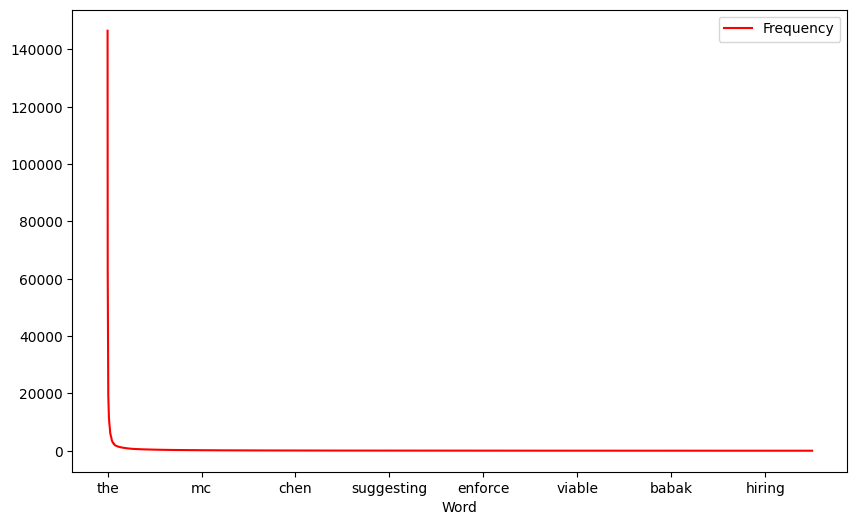

In [60]:
import pandas as pd

# Get the feature names (words) from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Sum the counts for each word across all documents in X_train
word_counts = X_train.sum(axis=0)

# Create a dictionary of word frequencies
word_frequency = dict(zip(feature_names, word_counts.tolist()[0]))

# Convert to a DataFrame for better visualization and sorting
word_freq_df = pd.DataFrame(word_frequency.items(), columns=['Word', 'Frequency'])
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# Plot the word_freq_df
word_freq_df.head(15000).plot(kind='line', x='Word', y='Frequency', color='red', figsize=(10, 6))

# Part 2

## TODO 2.1

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


model = LogisticRegression(C=10000)
model.fit(X_train, y_train)

print(f"It took {model.n_iter_[0]} iterations till it is done")

y_train_pred = model.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)
print(f"The prediction accuracy on the training set: {acc_train}")
y_test_pred = model.predict(X_test)
acc_test = accuracy_score(y_test, y_test_pred)
print(f"The prediction accuracy on the test set: {acc_test}")

It took 74 iterations till it is done
The prediction accuracy on the training set: 0.999734841788934
The prediction accuracy on the test set: 0.762745618693574


The prediction accuracy on the training set: 0.9997

The prediction accuracy on the test set: 0.7627

## TODO 2.2

In [62]:
model_high_reg = LogisticRegression(C=0.01, max_iter=1000)
model_high_reg.fit(X_train, y_train)

y_train_pred_high_reg = model_high_reg.predict(X_train)
acc_train_high_reg = accuracy_score(y_train, y_train_pred_high_reg)
print(f"The prediction accuracy on the training set with high regularization: {acc_train_high_reg}")
y_test_pred_high_reg = model_high_reg.predict(X_test)
acc_test_high_reg = accuracy_score(y_test, y_test_pred_high_reg)
print(f"The prediction accuracy on the test set with high regularization: {acc_test_high_reg}")

model_medium_reg_lg = LogisticRegression(C=1, max_iter=1000)
model_medium_reg_lg.fit(X_train, y_train)

y_train_pred_medium_reg = model_medium_reg_lg.predict(X_train)
acc_train_medium_reg = accuracy_score(y_train, y_train_pred_medium_reg)
print(f"The prediction accuracy on the training set with medium regularization: {acc_train_medium_reg}")
y_test_pred_medium_reg = model_medium_reg_lg.predict(X_test)
acc_test_medium_reg = accuracy_score(y_test, y_test_pred_medium_reg)
print(f"The prediction accuracy on the test set with medium regularization: {acc_test_medium_reg}")

The prediction accuracy on the training set with high regularization: 0.9545695598373697
The prediction accuracy on the test set with high regularization: 0.7606213489113117
The prediction accuracy on the training set with medium regularization: 0.9999116139296447
The prediction accuracy on the test set with medium regularization: 0.7812002124269782


Regularization is necessary in high-dimensional text classification problems. In this dataset, the bag-of-words representation contains over 25,000 features (one per token), while the number of training samples is much smaller. When the number of features is large relative to the number of observations, the model can easily overfit by assigning large weights to rare or noisy words. This leads to very high training accuracy but poorer generalization on unseen data. Regularization adds a penalty on large coefficient values. This encourages the model to distribute weight more evenly across features and reduces sensitivity to individual noisy tokens.

In section 2.1, I initially set C=1000 like in the demo code and saw around really high training accuracy and lower prediction accuracy. When I tried the othe extreme, C=0.01, I saw that the training accuracy decreased a substantial amount and the prediction accuracy was actually slightly poorer. Lastly, I choose C=1 (inbetween 0.01 and 1000) and prediction accuracy was 2 percentage points higher than for other values of C. A smaller C = stronger regularization and a larger C = weaker regularization.

# Part 3

## TODO 3.1

In [63]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    hidden_layer_sizes=(100,), 
    activation='relu', 
    solver='sgd', 
    learning_rate="adaptive",
    learning_rate_init=0.01,
    alpha=0.001, 
    max_iter=50, 
    random_state=42
)

model_mlp.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model_mlp.predict(X_train))
test_acc = accuracy_score(y_test, model_mlp.predict(X_test))

print("MLP train acc:", train_acc)
print("MLP test acc:", test_acc)
print("MLP iters:", model_mlp.n_iter_)



MLP train acc: 0.9996464557185788
MLP test acc: 0.783457249070632
MLP iters: 50


/Users/almas/Downloads/Documents/Projects/VSCode_Projects/NLP/HW1/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


**Hidden Layer Architecture:**  
I used an MLP with hidden_layer_sizes=(100,), which is a single hidden layer with 100 units. I wanted to ensure that the model can learn non-linear combinations of word features while keeping the model relatively simple to train and less prone to overfitting compared to deeper networks.

**Activation Function:**  
I chose ReLU (activation="relu"). ReLU is commonly used because it trains efficiently with SGD and helps avoid vanishing gradients that can occur with tanh or simoid activations in deeper networks (due to chain rule). ReLU typically converges faster and works well for sparse high-dimensional inputs.

**Optimizer:**  
I set learning_rate_init=0.01 with learning_rate="adaptive". I selected this learning rate by trying a small set of values (0.1, 0.01, 0.001) and choosing the one that produced stable training and the best test accuracy without obvious divergence. With adaptive, the effective learning rate is reduced when progress stalls, which improves stability for SGD.

**Regularization:**  
I used alpha=0.001. In MLPClassifier, alpha controls the strength of L2 regularizatoin term (a penalty on large weights). Larger alpha means stronger regularization (smaller weights), which can reduce overfitting in high-dimensional text settings. In logistic regression, regularization strength is controlled by C, where larger C means weaker regularization. So, MLP uses alpha directly as the penalty strength (bigger alpha = more regularization), whereas logistic regression uses C as an inverse regularization parameter (bigger C = less regularization).

# Part 4

## TODO 4.1

In [64]:
from sklearn.metrics import accuracy_score
import pandas as pd

log_reg_preds = model_medium_reg_lg.predict(X_test)
log_reg_acc = accuracy_score(y_test, log_reg_preds)

mlp_preds = model_mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, mlp_preds)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP"],
    "Test Accuracy": [log_reg_acc, mlp_acc]
})

comparison_df

,Model,Test Accuracy
0,Logistic Regression,0.781200
1,MLP,0.783457


The MLP achieved a test accuracy of 0.7835, slightly higher than Logistic Regression (0.7812). 

However, the improvement is marginal (~0.2 percentage points). This suggests that for bag-of-words features, a linear model like Logistic Regression already captures most of the useful signal. The added non-linearity of the MLP does not provide a substantial advantage in this setting.

This aligns with common findings I read in text classification: high-dimensional sparse representations are often well-handled by linear models.

## TODO 4.2

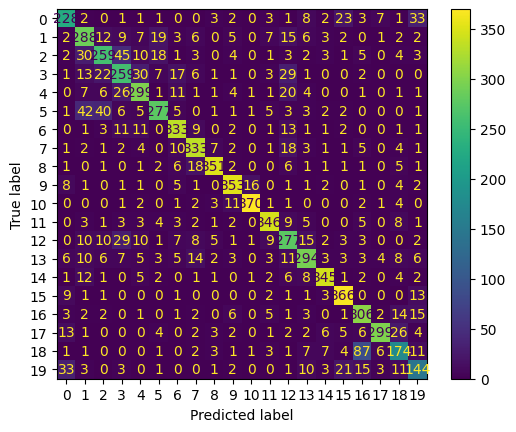

Most challenging label: talk.politics.misc
Number of errors: 136


In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import numpy as np

y_pred = model_mlp.predict(X_test)

mlp_cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=mlp_cm, display_labels=model_mlp.classes_)
disp.plot()
plt.show()

# Errors per class = total actual - correct predictions
errors_per_class = mlp_cm.sum(axis=1) - np.diag(mlp_cm)

most_confused_idx = np.argmax(errors_per_class)
most_confused_label = train_data.target_names[most_confused_idx]

print("Most challenging label:", most_confused_label)
print("Number of errors:", errors_per_class[most_confused_idx])

Based on the confusion matrix, the most challenging category was talk.politics.misc, with 136 misclassified examples.

This result is not surprising. The talk.politics.misc category is broad and less clearly defined than other political categories such as talk.politics.guns or talk.politics.mideast. Because it covers general political discussion, its vocabulary overlaps heavily with more specific political topics. 

From the confusion matrix, many of its errors appear to occur with other political categories, particularly talk.politics.guns and talk.politics.mideast. These categories share common terminology such as government, policy, rights, law, and conflict. Since we are using a bag-of-words representation, the model relies purely on word frequency and cannot distinguish nuanced contextual differences between closely related political discussions.

Additionally, our preprocessing choice of min_df=5 removes rare words. While this helps reduce noise, it may also remove unique low-frequency terms that could help differentiate general political discussions from more specialized political subtopics.

Overall, the confusion matrix suggests that the model performs well on clearly distinct categories but struggles with semantically overlapping political topics, highlighting a limitation of bag-of-words features.